[*********************100%***********************]  1 of 1 completed


Últimos valores:
Precio actual : 493.44
MA20          : 500.54
MA100         : 536.05
MA200         : 552.01
Conclusión    : Tendencia bajista fuerte
Evento técnico: Sin cruce reciente entre MA100 y MA200


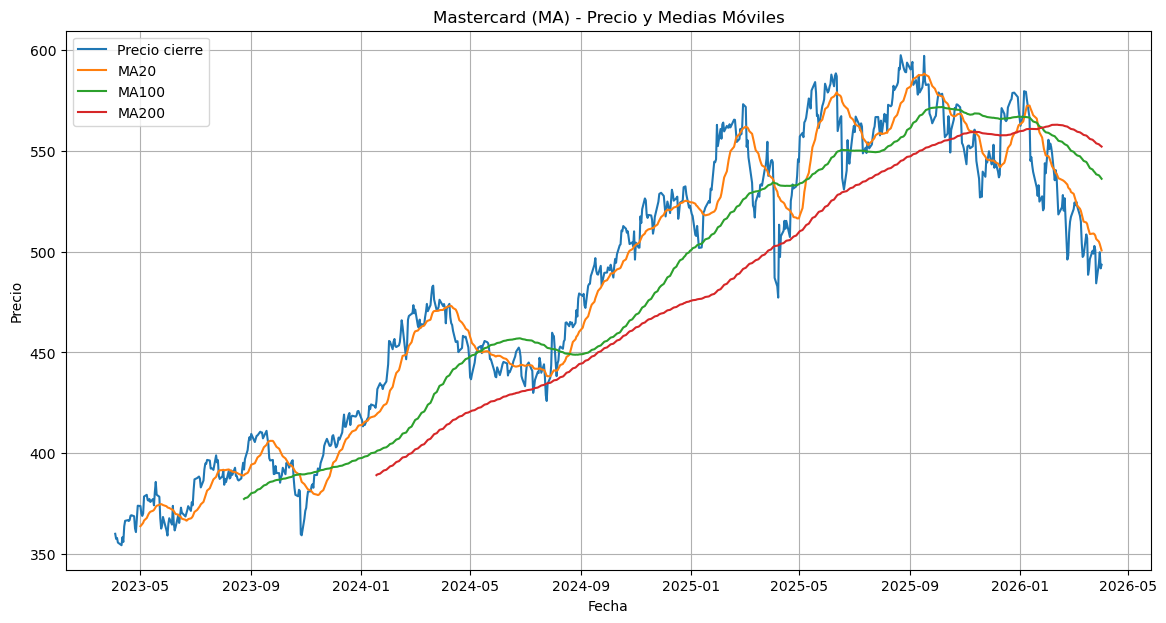

In [1]:
# Si falta instalar:
# !pip install yfinance pandas matplotlib

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1) Descargar datos de Mastercard
# -----------------------------
ticker = "MA"   # Mastercard
df = yf.download(ticker, period="3y", interval="1d", auto_adjust=True)

if df.empty:
    raise ValueError("No se pudieron descargar datos.")

# Asegurar serie 1D
close = df["Close"]
if isinstance(close, pd.DataFrame):
    close = close.squeeze()

# -----------------------------
# 2) Medias móviles
# -----------------------------
df["MA20"] = close.rolling(20).mean()
df["MA100"] = close.rolling(100).mean()
df["MA200"] = close.rolling(200).mean()

# -----------------------------
# 3) Señal simple
# -----------------------------
precio = float(close.iloc[-1])
ma20 = float(df["MA20"].iloc[-1])
ma100 = float(df["MA100"].iloc[-1])
ma200 = float(df["MA200"].iloc[-1])

if precio > ma20 > ma100 > ma200:
    señal = "Tendencia alcista fuerte"
elif precio > ma100 and precio > ma200:
    señal = "Sesgo alcista"
elif precio < ma20 < ma100 < ma200:
    señal = "Tendencia bajista fuerte"
elif precio < ma100 and precio < ma200:
    señal = "Sesgo bajista"
else:
    señal = "Zona mixta / sin señal clara"

# -----------------------------
# 4) Mostrar resultados
# -----------------------------
print("Últimos valores:")
print(f"Precio actual : {precio:.2f}")
print(f"MA20          : {ma20:.2f}")
print(f"MA100         : {ma100:.2f}")
print(f"MA200         : {ma200:.2f}")
print(f"Conclusión    : {señal}")

# -----------------------------
# 5) Regla práctica extra
# -----------------------------
golden_cross = (df["MA100"].iloc[-2] <= df["MA200"].iloc[-2]) and (df["MA100"].iloc[-1] > df["MA200"].iloc[-1])
death_cross  = (df["MA100"].iloc[-2] >= df["MA200"].iloc[-2]) and (df["MA100"].iloc[-1] < df["MA200"].iloc[-1])

if golden_cross:
    print("Evento técnico: Golden Cross (MA100 cruza sobre MA200)")
elif death_cross:
    print("Evento técnico: Death Cross (MA100 cruza bajo MA200)")
else:
    print("Evento técnico: Sin cruce reciente entre MA100 y MA200")

# -----------------------------
# 6) Gráfico
# -----------------------------
plt.figure(figsize=(14,7))
plt.plot(close.index, close, label="Precio cierre")
plt.plot(df.index, df["MA20"], label="MA20")
plt.plot(df.index, df["MA100"], label="MA100")
plt.plot(df.index, df["MA200"], label="MA200")
plt.title("Mastercard (MA) - Precio y Medias Móviles")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.grid(True)
plt.show()

[*********************100%***********************]  1 of 1 completed



===== V =====
Precio: 300.8
MA20: 305.23
MA50: 315.64
MA100: 326.65
MA200: 335.44
RSI14: 42.91
Volumen>Prom20: False
Señal: NO COMPRAR
Motivo: precio bajo medias largas + tendencia bajista
Alertas: RSI débil, volumen bajo, MA200 débil


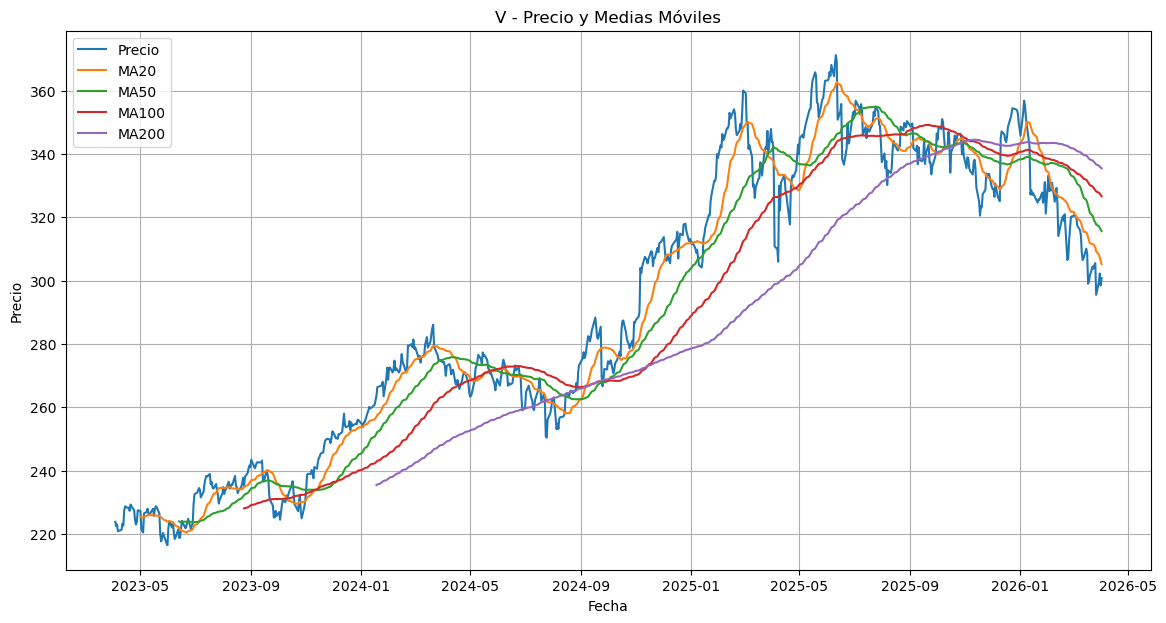

[*********************100%***********************]  1 of 1 completed



===== VOO =====
Precio: 602.99
MA20: 604.95
MA50: 620.48
MA100: 622.04
MA200: 605.73
RSI14: 47.49
Volumen>Prom20: False
Señal: ESPERAR
Motivo: estructura mixta, sin ventaja clara
Alertas: volumen bajo


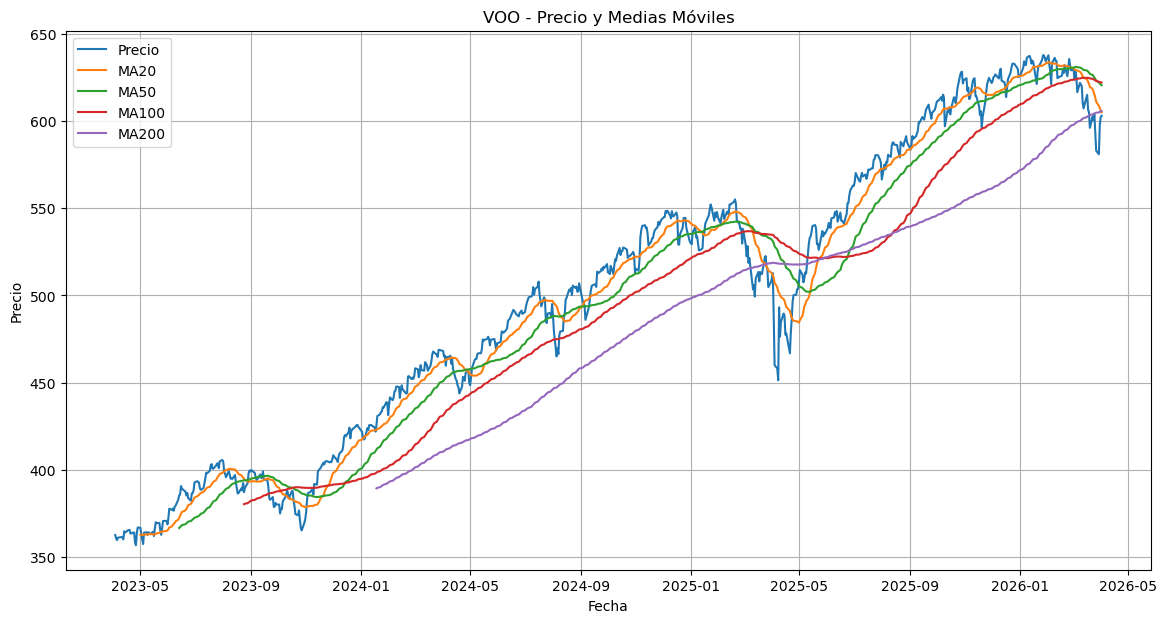


================ RESUMEN FINAL ================



,Ticker,Precio,MA20,MA50,MA100,MA200,RSI14,Volumen>Prom20,Señal,Motivo,Alertas
0,V,300.80,305.23,315.64,326.65,335.44,42.91,False,NO COMPRAR,precio bajo medias largas + tendencia bajista,"RSI débil, volumen bajo, MA200 débil"
1,VOO,602.99,604.95,620.48,622.04,605.73,47.49,False,ESPERAR,"estructura mixta, sin ventaja clara",volumen bajo


In [2]:
# ============================================================
# ANALISIS TECNICO SIMPLE: VISA (V) y VOO
# Jupyter Lab / Python
# ============================================================
# Si falta instalar:
# !pip install yfinance pandas matplotlib

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
tickers = ["V", "VOO"]
periodo = "3y"
intervalo = "1d"

# ------------------------------------------------------------
# FUNCIONES
# ------------------------------------------------------------
def calcular_rsi(serie, periodo=14):
    delta = serie.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(periodo).mean()
    avg_loss = loss.rolling(periodo).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

def evaluar_activo(df):
    close = df["Close"]
    vol = df["Volume"]

    df["MA20"] = close.rolling(20).mean()
    df["MA50"] = close.rolling(50).mean()
    df["MA100"] = close.rolling(100).mean()
    df["MA200"] = close.rolling(200).mean()
    df["RSI14"] = calcular_rsi(close, 14)
    df["VOL20"] = vol.rolling(20).mean()

    ult = df.iloc[-1]
    prev = df.iloc[-2]

    precio = float(ult["Close"])
    ma20 = float(ult["MA20"])
    ma50 = float(ult["MA50"])
    ma100 = float(ult["MA100"])
    ma200 = float(ult["MA200"])
    rsi = float(ult["RSI14"])
    vol_actual = float(ult["Volume"])
    vol20 = float(ult["VOL20"])

    # Pendientes simples
    pendiente_ma20 = ult["MA20"] - prev["MA20"]
    pendiente_ma50 = ult["MA50"] - prev["MA50"]
    pendiente_ma200 = ult["MA200"] - prev["MA200"]

    # Señales
    sobre_ma20 = precio > ma20
    sobre_ma50 = precio > ma50
    sobre_ma100 = precio > ma100
    sobre_ma200 = precio > ma200

    orden_alcista = ma20 > ma50 > ma100 > ma200
    orden_bajista = ma20 < ma50 < ma100 < ma200

    volumen_fuerte = vol_actual > vol20
    rsi_sano = 50 <= rsi <= 70
    rsi_sobrecompra = rsi > 70
    rsi_debil = rsi < 45

    # Clasificación
    if sobre_ma20 and sobre_ma50 and sobre_ma100 and sobre_ma200 and orden_alcista and pendiente_ma20 > 0 and pendiente_ma50 > 0:
        if rsi_sano:
            señal = "COMPRAR"
            motivo = "precio sobre todas las medias + tendencia alcista + RSI sano"
        elif rsi_sobrecompra:
            señal = "ESPERAR"
            motivo = "tendencia alcista, pero RSI alto"
        else:
            señal = "COMPRAR"
            motivo = "tendencia alcista clara"
    elif (not sobre_ma100) and (not sobre_ma200) and orden_bajista and pendiente_ma20 < 0 and pendiente_ma50 < 0:
        señal = "NO COMPRAR"
        motivo = "precio bajo medias largas + tendencia bajista"
    else:
        señal = "ESPERAR"
        motivo = "estructura mixta, sin ventaja clara"

    # Riesgo adicional
    riesgo = []
    if rsi_sobrecompra:
        riesgo.append("RSI alto")
    if rsi_debil:
        riesgo.append("RSI débil")
    if not volumen_fuerte:
        riesgo.append("volumen bajo")
    if pendiente_ma200 < 0:
        riesgo.append("MA200 débil")

    if len(riesgo) == 0:
        riesgo_txt = "sin alertas técnicas relevantes"
    else:
        riesgo_txt = ", ".join(riesgo)

    resumen = {
        "Precio": round(precio, 2),
        "MA20": round(ma20, 2),
        "MA50": round(ma50, 2),
        "MA100": round(ma100, 2),
        "MA200": round(ma200, 2),
        "RSI14": round(rsi, 2),
        "Volumen>Prom20": volumen_fuerte,
        "Señal": señal,
        "Motivo": motivo,
        "Alertas": riesgo_txt
    }

    return df, resumen

def graficar_activo(df, ticker):
    plt.figure(figsize=(14, 7))
    plt.plot(df.index, df["Close"], label="Precio")
    plt.plot(df.index, df["MA20"], label="MA20")
    plt.plot(df.index, df["MA50"], label="MA50")
    plt.plot(df.index, df["MA100"], label="MA100")
    plt.plot(df.index, df["MA200"], label="MA200")
    plt.title(f"{ticker} - Precio y Medias Móviles")
    plt.xlabel("Fecha")
    plt.ylabel("Precio")
    plt.legend()
    plt.grid(True)
    plt.show()

# ------------------------------------------------------------
# DESCARGA Y ANALISIS
# ------------------------------------------------------------
resultados = []

for ticker in tickers:
    df = yf.download(ticker, period=periodo, interval=intervalo, auto_adjust=True)

    if df.empty:
        print(f"No se pudo descargar {ticker}")
        continue

    # normalizar columnas por si vienen en multiindex
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df, resumen = evaluar_activo(df)
    resumen["Ticker"] = ticker
    resultados.append(resumen)

    print(f"\n===== {ticker} =====")
    for k, v in resumen.items():
        if k != "Ticker":
            print(f"{k}: {v}")

    graficar_activo(df, ticker)

# ------------------------------------------------------------
# TABLA FINAL
# ------------------------------------------------------------
tabla = pd.DataFrame(resultados)[[
    "Ticker", "Precio", "MA20", "MA50", "MA100", "MA200",
    "RSI14", "Volumen>Prom20", "Señal", "Motivo", "Alertas"
]]

print("\n================ RESUMEN FINAL ================\n")
display(tabla)


ANALIZANDO V


[*********************100%***********************]  1 of 1 completed


Ticker: V
Precio actual: 300.8
Tendencia: BAJISTA
RSI14: 42.91
Precio esperado 30d: 303.76
Mediana 30d: 303.23
Escenario pesimista P10: 277.35
Rango P25: 288.25
Rango P75: 317.13
Escenario optimista P90: 332.19
Probabilidad de subir (%): 54.2
Retorno esperado (%): 0.98
Señal final: ESPERAR
Media retorno log diario histórico: 0.000248
Volatilidad diaria histórica      : 0.012984


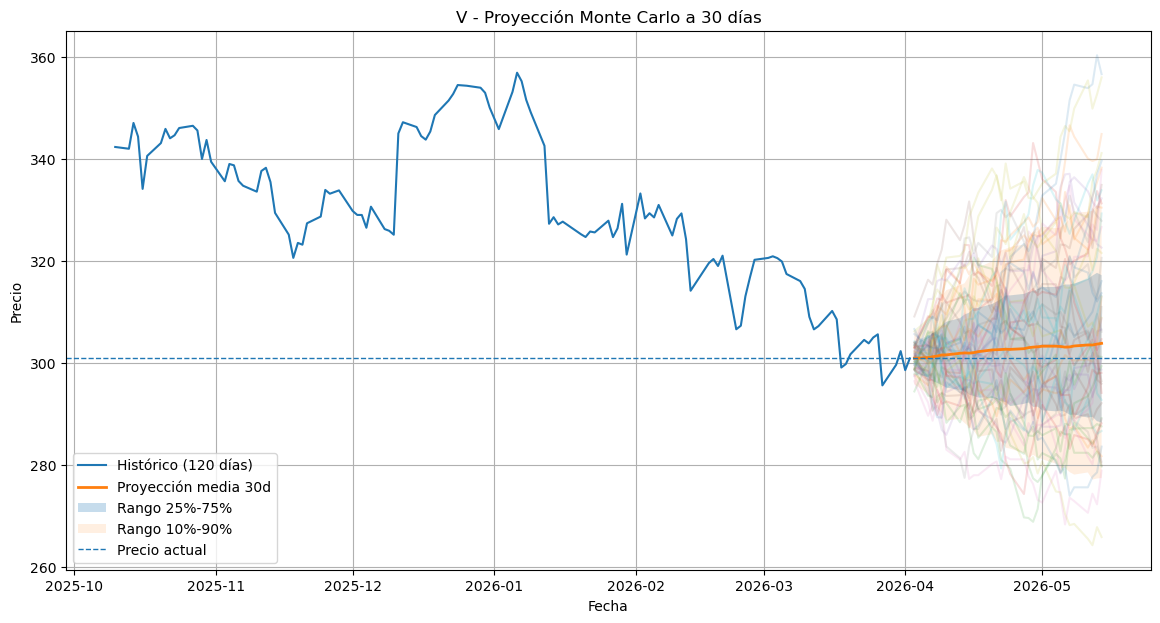


ANALIZANDO VOO


[*********************100%***********************]  1 of 1 completed


Ticker: VOO
Precio actual: 602.99
Tendencia: MIXTA
RSI14: 47.49
Precio esperado 30d: 615.78
Mediana 30d: 615.25
Escenario pesimista P10: 572.55
Rango P25: 592.45
Rango P75: 637.63
Escenario optimista P90: 658.59
Probabilidad de subir (%): 63.5
Retorno esperado (%): 2.12
Señal final: ESPERAR
Media retorno log diario histórico: 0.000645
Volatilidad diaria histórica      : 0.009885


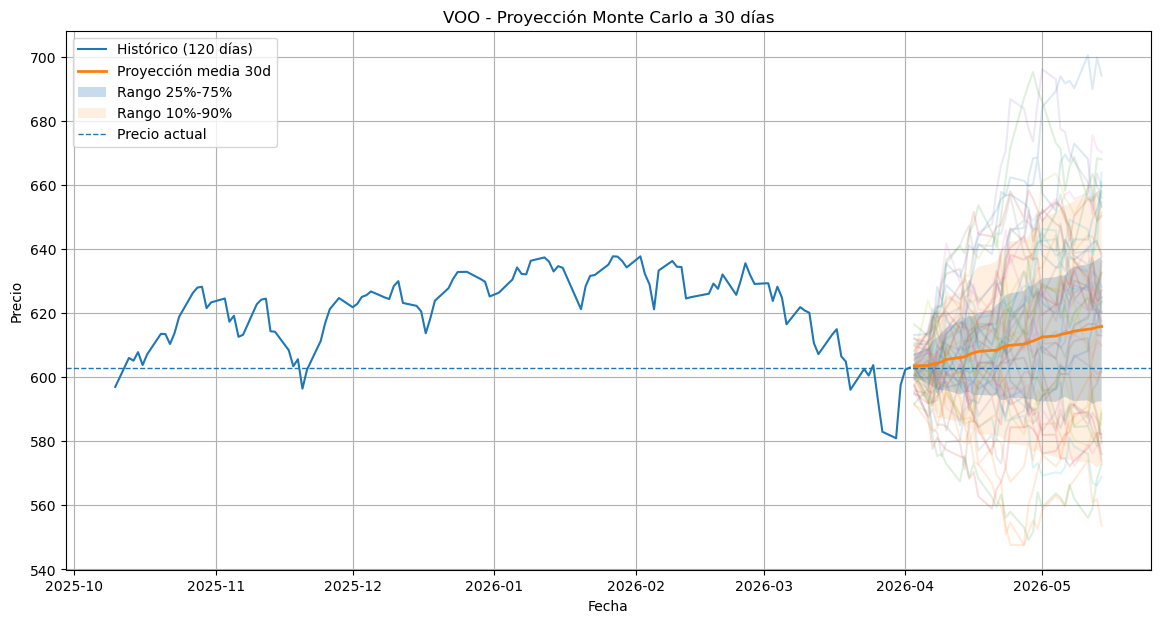


==================== RESUMEN FINAL ====================



,Ticker,Precio actual,Tendencia,RSI14,Precio esperado 30d,Mediana 30d,Escenario pesimista P10,Rango P25,Rango P75,Escenario optimista P90,Probabilidad de subir (%),Retorno esperado (%),Señal final
0,V,300.80,BAJISTA,42.91,303.76,303.23,277.35,288.25,317.13,332.19,54.2,0.98,ESPERAR
1,VOO,602.99,MIXTA,47.49,615.78,615.25,572.55,592.45,637.63,658.59,63.5,2.12,ESPERAR


In [3]:
# ============================================================
# PROYECCION SIMPLE PARA VISA (V) y VOO - 30 DIAS
# Metodo:
# 1) Tendencia tecnica (MA20, MA50, MA100, MA200)
# 2) Retornos logaritmicos
# 3) Monte Carlo (1000 simulaciones)
# 4) Rango esperado + probabilidad de subir
#
# Jupyter Lab / Python
# ============================================================

# Si falta instalar:
# !pip install yfinance pandas numpy matplotlib

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# CONFIGURACION
# ------------------------------------------------------------
tickers = ["V", "VOO"]
periodo_hist = "3y"
dias_proyeccion = 30
n_simulaciones = 1000
np.random.seed(42)

# ------------------------------------------------------------
# FUNCIONES
# ------------------------------------------------------------
def calcular_rsi(serie, periodo=14):
    delta = serie.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(periodo).mean()
    avg_loss = loss.rolling(periodo).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

def descargar_datos(ticker, period="3y"):
    df = yf.download(ticker, period=period, interval="1d", auto_adjust=True)
    if df.empty:
        raise ValueError(f"No se pudieron descargar datos de {ticker}")

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    return df[["Close", "Volume"]].dropna()

def preparar_indicadores(df):
    df = df.copy()
    df["MA20"] = df["Close"].rolling(20).mean()
    df["MA50"] = df["Close"].rolling(50).mean()
    df["MA100"] = df["Close"].rolling(100).mean()
    df["MA200"] = df["Close"].rolling(200).mean()
    df["RSI14"] = calcular_rsi(df["Close"], 14)
    df["RetLog"] = np.log(df["Close"] / df["Close"].shift(1))
    return df.dropna()

def clasificar_tendencia(df):
    ult = df.iloc[-1]
    prev = df.iloc[-2]

    precio = ult["Close"]
    ma20 = ult["MA20"]
    ma50 = ult["MA50"]
    ma100 = ult["MA100"]
    ma200 = ult["MA200"]
    rsi = ult["RSI14"]

    pendiente_ma20 = ult["MA20"] - prev["MA20"]
    pendiente_ma50 = ult["MA50"] - prev["MA50"]
    pendiente_ma200 = ult["MA200"] - prev["MA200"]

    if (precio > ma20 > ma50 > ma100 > ma200) and (pendiente_ma20 > 0) and (pendiente_ma50 > 0):
        if rsi > 70:
            return "ALCISTA PERO EXTENDIDA"
        return "ALCISTA"
    elif (precio < ma20 < ma50 < ma100 < ma200) and (pendiente_ma20 < 0) and (pendiente_ma50 < 0):
        return "BAJISTA"
    elif precio > ma200 and pendiente_ma200 >= 0:
        return "NEUTRA-ALCISTA"
    elif precio < ma200 and pendiente_ma200 <= 0:
        return "NEUTRA-BAJISTA"
    else:
        return "MIXTA"

def simular_montecarlo(df, dias=30, n_sims=1000):
    ret = df["RetLog"].dropna()

    # media y volatilidad diaria historica
    mu = ret.mean()
    sigma = ret.std()

    precio_inicial = df["Close"].iloc[-1]

    simulaciones = np.zeros((dias, n_sims))

    for sim in range(n_sims):
        shocks = np.random.normal(mu, sigma, dias)
        trayectoria = [precio_inicial]

        for shock in shocks:
            nuevo_precio = trayectoria[-1] * np.exp(shock)
            trayectoria.append(nuevo_precio)

        simulaciones[:, sim] = trayectoria[1:]

    return simulaciones, mu, sigma

def resumir_proyeccion(df, simulaciones, ticker):
    precio_actual = df["Close"].iloc[-1]

    precios_finales = simulaciones[-1, :]
    precio_medio = np.mean(precios_finales)
    precio_mediana = np.median(precios_finales)
    p10 = np.percentile(precios_finales, 10)
    p25 = np.percentile(precios_finales, 25)
    p75 = np.percentile(precios_finales, 75)
    p90 = np.percentile(precios_finales, 90)

    prob_subir = np.mean(precios_finales > precio_actual) * 100
    retorno_esperado = ((precio_medio / precio_actual) - 1) * 100

    tendencia = clasificar_tendencia(df)
    rsi = df["RSI14"].iloc[-1]

    # Señal final simple
    if tendencia in ["ALCISTA", "NEUTRA-ALCISTA"] and prob_subir >= 55:
        señal = "FAVORABLE"
    elif tendencia == "BAJISTA" and prob_subir < 50:
        señal = "DESFAVORABLE"
    else:
        señal = "ESPERAR"

    resumen = {
        "Ticker": ticker,
        "Precio actual": round(precio_actual, 2),
        "Tendencia": tendencia,
        "RSI14": round(rsi, 2),
        "Precio esperado 30d": round(precio_medio, 2),
        "Mediana 30d": round(precio_mediana, 2),
        "Escenario pesimista P10": round(p10, 2),
        "Rango P25": round(p25, 2),
        "Rango P75": round(p75, 2),
        "Escenario optimista P90": round(p90, 2),
        "Probabilidad de subir (%)": round(prob_subir, 2),
        "Retorno esperado (%)": round(retorno_esperado, 2),
        "Señal final": señal
    }

    return resumen

def graficar_proyeccion(df, simulaciones, ticker, dias=30):
    precio_actual = df["Close"].iloc[-1]

    plt.figure(figsize=(14, 7))

    # historial corto (últimos 120 días)
    hist = df["Close"].tail(120)
    plt.plot(hist.index, hist.values, label="Histórico (120 días)")

    # eje futuro
    fechas_futuras = pd.bdate_range(start=df.index[-1], periods=dias + 1)[1:]

    # algunas simulaciones visibles
    for i in range(min(50, simulaciones.shape[1])):
        plt.plot(fechas_futuras, simulaciones[:, i], alpha=0.15)

    # media y bandas
    media = simulaciones.mean(axis=1)
    p25 = np.percentile(simulaciones, 25, axis=1)
    p75 = np.percentile(simulaciones, 75, axis=1)
    p10 = np.percentile(simulaciones, 10, axis=1)
    p90 = np.percentile(simulaciones, 90, axis=1)

    plt.plot(fechas_futuras, media, linewidth=2, label="Proyección media 30d")
    plt.fill_between(fechas_futuras, p25, p75, alpha=0.25, label="Rango 25%-75%")
    plt.fill_between(fechas_futuras, p10, p90, alpha=0.12, label="Rango 10%-90%")

    plt.axhline(precio_actual, linestyle="--", linewidth=1, label="Precio actual")

    plt.title(f"{ticker} - Proyección Monte Carlo a {dias} días")
    plt.xlabel("Fecha")
    plt.ylabel("Precio")
    plt.legend()
    plt.grid(True)
    plt.show()

# ------------------------------------------------------------
# EJECUCION
# ------------------------------------------------------------
resultados = []

for ticker in tickers:
    print(f"\n{'='*60}")
    print(f"ANALIZANDO {ticker}")
    print(f"{'='*60}")

    df = descargar_datos(ticker, period=periodo_hist)
    df = preparar_indicadores(df)

    simulaciones, mu, sigma = simular_montecarlo(df, dias=dias_proyeccion, n_sims=n_simulaciones)
    resumen = resumir_proyeccion(df, simulaciones, ticker)
    resultados.append(resumen)

    for k, v in resumen.items():
        print(f"{k}: {v}")

    print(f"Media retorno log diario histórico: {mu:.6f}")
    print(f"Volatilidad diaria histórica      : {sigma:.6f}")

    graficar_proyeccion(df, simulaciones, ticker, dias=dias_proyeccion)

# ------------------------------------------------------------
# TABLA FINAL
# ------------------------------------------------------------
tabla = pd.DataFrame(resultados)
print("\n==================== RESUMEN FINAL ====================\n")
display(tabla)

   ---------------------------------------- 0.0/929.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/929.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/929.7 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/929.7 kB ? eta -:--:--
   ---------------------------------------- 929.7/929.7 kB 4.9 MB/s  0:00:00

ANALISIS AVANZADO: V


[*********************100%***********************]  1 of 1 completed


Ticker: V
Precio actual: 300.8
Tendencia: BAJISTA
RSI14: 42.91
Precio esperado 30d: 304.81
Mediana 30d: 304.25
P10: 276.11
P25: 288.73
P75: 319.13
P90: 334.54
Prob. subir (%): 55.6
Retorno esperado (%): 1.33
Señal final: ESPERAR

--- Extras técnicos ---
ARIMA AIC: -6000.28
Volatilidad GARCH día 1 : 1.3748%
Volatilidad GARCH día 30: 1.3465%


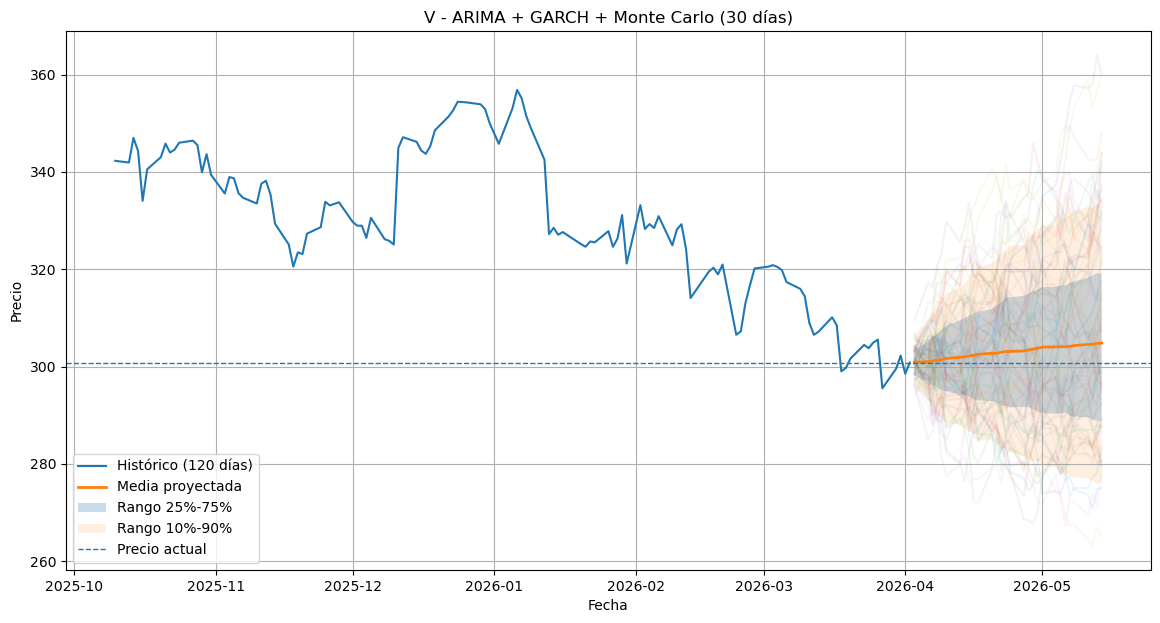


ANALISIS AVANZADO: VOO


[*********************100%***********************]  1 of 1 completed


Ticker: VOO
Precio actual: 602.99
Tendencia: MIXTA
RSI14: 47.49
Precio esperado 30d: 612.15
Mediana 30d: 611.88
P10: 562.7
P25: 584.63
P75: 638.54
P90: 662.67
Prob. subir (%): 57.85
Retorno esperado (%): 1.52
Señal final: ESPERAR

--- Extras técnicos ---
ARIMA AIC: -6517.17
Volatilidad GARCH día 1 : 1.2196%
Volatilidad GARCH día 30: 1.1440%


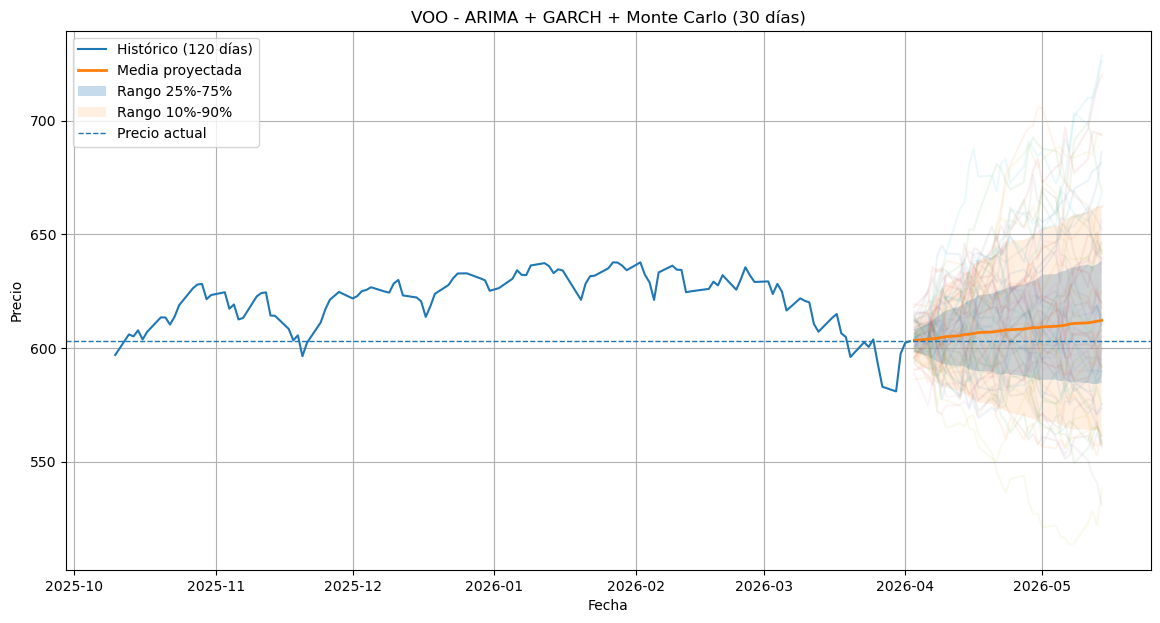


==================== RESUMEN COMPARATIVO ====================



,Ticker,Precio actual,Tendencia,RSI14,Precio esperado 30d,Mediana 30d,P10,P25,P75,P90,Prob. subir (%),Retorno esperado (%),Señal final
0,V,300.80,BAJISTA,42.91,304.81,304.25,276.11,288.73,319.13,334.54,55.60,1.33,ESPERAR
1,VOO,602.99,MIXTA,47.49,612.15,611.88,562.70,584.63,638.54,662.67,57.85,1.52,ESPERAR



==================== RANKING SIMPLE ====================



,Ticker,Prob. subir (%),Retorno esperado (%),Señal final,Score
1,VOO,57.85,1.52,ESPERAR,40.79
0,V,55.60,1.33,ESPERAR,38.68


In [ ]:
# ============================================================
# NEXT LEVEL: VISA (V) y VOO
# ARIMA (tendencia) + GARCH (volatilidad) + Monte Carlo (30d)
# Jupyter Lab / Python
# ============================================================
# Si falta instalar:
#!pip install yfinance pandas numpy matplotlib statsmodels arch scipy

import warnings
warnings.filterwarnings("ignore")

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
tickers = ["V", "VOO"]
periodo_hist = "5y"
dias_proyeccion = 30
n_simulaciones = 2000
np.random.seed(42)

# ------------------------------------------------------------
# FUNCIONES BASE
# ------------------------------------------------------------
def descargar_datos(ticker, period="5y"):
    df = yf.download(ticker, period=period, interval="1d", auto_adjust=True)
    if df.empty:
        raise ValueError(f"No se pudieron descargar datos de {ticker}")

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    return df[["Close", "Volume"]].dropna()

def calcular_rsi(serie, periodo=14):
    delta = serie.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(periodo).mean()
    avg_loss = loss.rolling(periodo).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

def preparar_indicadores(df):
    df = df.copy()
    df["MA20"] = df["Close"].rolling(20).mean()
    df["MA50"] = df["Close"].rolling(50).mean()
    df["MA100"] = df["Close"].rolling(100).mean()
    df["MA200"] = df["Close"].rolling(200).mean()
    df["RSI14"] = calcular_rsi(df["Close"], 14)
    df["RetLog"] = np.log(df["Close"] / df["Close"].shift(1))
    return df.dropna()

def clasificar_tendencia(df):
    ult = df.iloc[-1]
    prev = df.iloc[-2]

    precio = ult["Close"]
    ma20 = ult["MA20"]
    ma50 = ult["MA50"]
    ma100 = ult["MA100"]
    ma200 = ult["MA200"]
    rsi = ult["RSI14"]

    pendiente_ma20 = ult["MA20"] - prev["MA20"]
    pendiente_ma50 = ult["MA50"] - prev["MA50"]
    pendiente_ma200 = ult["MA200"] - prev["MA200"]

    if (precio > ma20 > ma50 > ma100 > ma200) and (pendiente_ma20 > 0) and (pendiente_ma50 > 0):
        if rsi > 70:
            return "ALCISTA PERO EXTENDIDA"
        return "ALCISTA"
    elif (precio < ma20 < ma50 < ma100 < ma200) and (pendiente_ma20 < 0) and (pendiente_ma50 < 0):
        return "BAJISTA"
    elif precio > ma200 and pendiente_ma200 >= 0:
        return "NEUTRA-ALCISTA"
    elif precio < ma200 and pendiente_ma200 <= 0:
        return "NEUTRA-BAJISTA"
    else:
        return "MIXTA"

# ------------------------------------------------------------
# ARIMA: tendencia de retornos
# ------------------------------------------------------------
def ajustar_arima_retornos(retornos):
    """
    Modelo simple y robusto: ARIMA(1,0,1) sobre retornos log
    """
    modelo = ARIMA(retornos, order=(1, 0, 1))
    ajuste = modelo.fit()
    forecast = ajuste.forecast(steps=dias_proyeccion)
    return ajuste, np.array(forecast)

# ------------------------------------------------------------
# GARCH: volatilidad condicional
# ------------------------------------------------------------
def ajustar_garch(retornos):
    """
    GARCH(1,1) clásico sobre retornos log * 100
    """
    ret_pct = retornos * 100
    modelo = arch_model(ret_pct, vol="Garch", p=1, q=1, mean="Zero", dist="normal")
    ajuste = modelo.fit(disp="off")

    # forecast de varianza a 30 días
    fc = ajuste.forecast(horizon=dias_proyeccion, reindex=False)
    var_futura = fc.variance.values[-1]  # array de largo 30
    sigma_futura = np.sqrt(var_futura) / 100.0  # volver a escala log-retorno

    return ajuste, sigma_futura

# ------------------------------------------------------------
# MONTE CARLO con drift ARIMA + vol GARCH
# ------------------------------------------------------------
def simular_arima_garch(precio_actual, drift_diario, sigma_diaria, dias=30, n_sims=2000):
    """
    drift_diario: array de retornos esperados (ARIMA) de largo=dias
    sigma_diaria: array de volatilidades (GARCH) de largo=dias
    """
    sims = np.zeros((dias, n_sims))

    for j in range(n_sims):
        precios = [precio_actual]

        for t in range(dias):
            shock = np.random.normal(loc=drift_diario[t], scale=sigma_diaria[t])
            nuevo_precio = precios[-1] * np.exp(shock)
            precios.append(nuevo_precio)

        sims[:, j] = precios[1:]

    return sims

# ------------------------------------------------------------
# RESUMEN FINAL
# ------------------------------------------------------------
def resumir_modelo(df, sims, ticker):
    precio_actual = df["Close"].iloc[-1]
    precios_finales = sims[-1, :]

    precio_esperado = np.mean(precios_finales)
    mediana = np.median(precios_finales)
    p10 = np.percentile(precios_finales, 10)
    p25 = np.percentile(precios_finales, 25)
    p75 = np.percentile(precios_finales, 75)
    p90 = np.percentile(precios_finales, 90)

    prob_subir = np.mean(precios_finales > precio_actual) * 100
    retorno_esperado = (precio_esperado / precio_actual - 1) * 100

    tendencia = clasificar_tendencia(df)
    rsi = df["RSI14"].iloc[-1]

    # Señal combinada más exigente
    if tendencia in ["ALCISTA", "NEUTRA-ALCISTA"] and prob_subir >= 58 and retorno_esperado > 1:
        señal = "FAVORABLE"
    elif tendencia in ["BAJISTA", "NEUTRA-BAJISTA"] and prob_subir < 50:
        señal = "DESFAVORABLE"
    else:
        señal = "ESPERAR"

    resumen = {
        "Ticker": ticker,
        "Precio actual": round(precio_actual, 2),
        "Tendencia": tendencia,
        "RSI14": round(rsi, 2),
        "Precio esperado 30d": round(precio_esperado, 2),
        "Mediana 30d": round(mediana, 2),
        "P10": round(p10, 2),
        "P25": round(p25, 2),
        "P75": round(p75, 2),
        "P90": round(p90, 2),
        "Prob. subir (%)": round(prob_subir, 2),
        "Retorno esperado (%)": round(retorno_esperado, 2),
        "Señal final": señal
    }

    return resumen

# ------------------------------------------------------------
# GRAFICO
# ------------------------------------------------------------
def graficar_proyeccion(df, sims, ticker, dias=30):
    precio_actual = df["Close"].iloc[-1]

    plt.figure(figsize=(14, 7))

    # Histórico corto
    hist = df["Close"].tail(120)
    plt.plot(hist.index, hist.values, label="Histórico (120 días)")

    # Fechas futuras
    fechas_futuras = pd.bdate_range(start=df.index[-1], periods=dias + 1)[1:]

    # Algunas trayectorias
    for i in range(min(60, sims.shape[1])):
        plt.plot(fechas_futuras, sims[:, i], alpha=0.08)

    # Bandas
    media = sims.mean(axis=1)
    p25 = np.percentile(sims, 25, axis=1)
    p75 = np.percentile(sims, 75, axis=1)
    p10 = np.percentile(sims, 10, axis=1)
    p90 = np.percentile(sims, 90, axis=1)

    plt.plot(fechas_futuras, media, linewidth=2, label="Media proyectada")
    plt.fill_between(fechas_futuras, p25, p75, alpha=0.25, label="Rango 25%-75%")
    plt.fill_between(fechas_futuras, p10, p90, alpha=0.12, label="Rango 10%-90%")

    plt.axhline(precio_actual, linestyle="--", linewidth=1, label="Precio actual")

    plt.title(f"{ticker} - ARIMA + GARCH + Monte Carlo ({dias} días)")
    plt.xlabel("Fecha")
    plt.ylabel("Precio")
    plt.legend()
    plt.grid(True)
    plt.show()

# ------------------------------------------------------------
# EJECUCION
# ------------------------------------------------------------
resultados = []

for ticker in tickers:
    print(f"\n{'='*70}")
    print(f"ANALISIS AVANZADO: {ticker}")
    print(f"{'='*70}")

    # 1) Datos
    df = descargar_datos(ticker, period=periodo_hist)
    df = preparar_indicadores(df)

    precio_actual = df["Close"].iloc[-1]
    retornos = df["RetLog"].dropna()

    # 2) ARIMA sobre retornos (drift esperado)
    arima_fit, drift_30d = ajustar_arima_retornos(retornos)

    # 3) GARCH sobre retornos (volatilidad condicional)
    garch_fit, sigma_30d = ajustar_garch(retornos)

    # 4) Monte Carlo usando drift ARIMA + sigma GARCH
    sims = simular_arima_garch(
        precio_actual=precio_actual,
        drift_diario=drift_30d,
        sigma_diaria=sigma_30d,
        dias=dias_proyeccion,
        n_sims=n_simulaciones
    )

    # 5) Resumen
    resumen = resumir_modelo(df, sims, ticker)
    resultados.append(resumen)

    for k, v in resumen.items():
        print(f"{k}: {v}")

    # Extra técnico útil
    print("\n--- Extras técnicos ---")
    print(f"ARIMA AIC: {arima_fit.aic:.2f}")
    print(f"Volatilidad GARCH día 1 : {sigma_30d[0]:.4%}")
    print(f"Volatilidad GARCH día 30: {sigma_30d[-1]:.4%}")

    # 6) Gráfico
    graficar_proyeccion(df, sims, ticker, dias=dias_proyeccion)

# ------------------------------------------------------------
# TABLA FINAL
# ------------------------------------------------------------
tabla = pd.DataFrame(resultados)
print("\n==================== RESUMEN COMPARATIVO ====================\n")
display(tabla)

# ------------------------------------------------------------
# OPCIONAL: ranking simple
# ------------------------------------------------------------
tabla_rank = tabla.copy()
tabla_rank["Score"] = (
    tabla_rank["Prob. subir (%)"] * 0.6 +
    tabla_rank["Retorno esperado (%)"] * 4.0
)

tabla_rank = tabla_rank.sort_values("Score", ascending=False)

print("\n==================== RANKING SIMPLE ====================\n")
display(tabla_rank[["Ticker", "Prob. subir (%)", "Retorno esperado (%)", "Señal final", "Score"]])


ANALISIS ROBUSTO: V

--- Comparación ARIMA (sí tiene sentido ahora) ---


,ARIMA,AIC,BIC
0,"(1, 0, 0)",-6005.283501,-5990.393931
1,"(2, 0, 0)",-6003.471365,-5983.618605
2,"(2, 0, 1)",-6001.460754,-5976.644804
3,"(1, 0, 1)",-6000.277270,-5980.424510
4,"(1, 1, 1)",-5991.600171,-5976.713441
5,"(2, 1, 1)",-5989.766499,-5969.917525
6,"(2, 1, 0)",-5679.646166,-5664.759435
7,"(1, 1, 0)",-5572.906435,-5562.981948



--- Resultado integrado ---
Ticker: V
Precio actual: 300.80
Tendencia técnica: BAJISTA
RSI14: 42.91
Mejor ARIMA: (1, 0, 0)
AIC mejor ARIMA: -6005.28
BIC mejor ARIMA: -5990.39
Volatilidad GARCH día 1: 1.3748%
Precio esperado 30d: 304.73
Mediana 30d (P50): 303.98
P10: 277.16
P25: 288.68
P75: 318.56
P90: 334.36
Probabilidad de subir: 55.33%
Retorno esperado: 1.31%
Ancho banda P25-P75: 29.88
Ancho banda P10-P90: 57.20
Score final: -2
SEÑAL FINAL: DESFAVORABLE

--- Interpretación de bandas Monte Carlo ---
P25-P75: banda central donde cae el 50% de los escenarios.
P10-P90: banda amplia donde cae el 80% de los escenarios.
Más ancha = más incertidumbre.


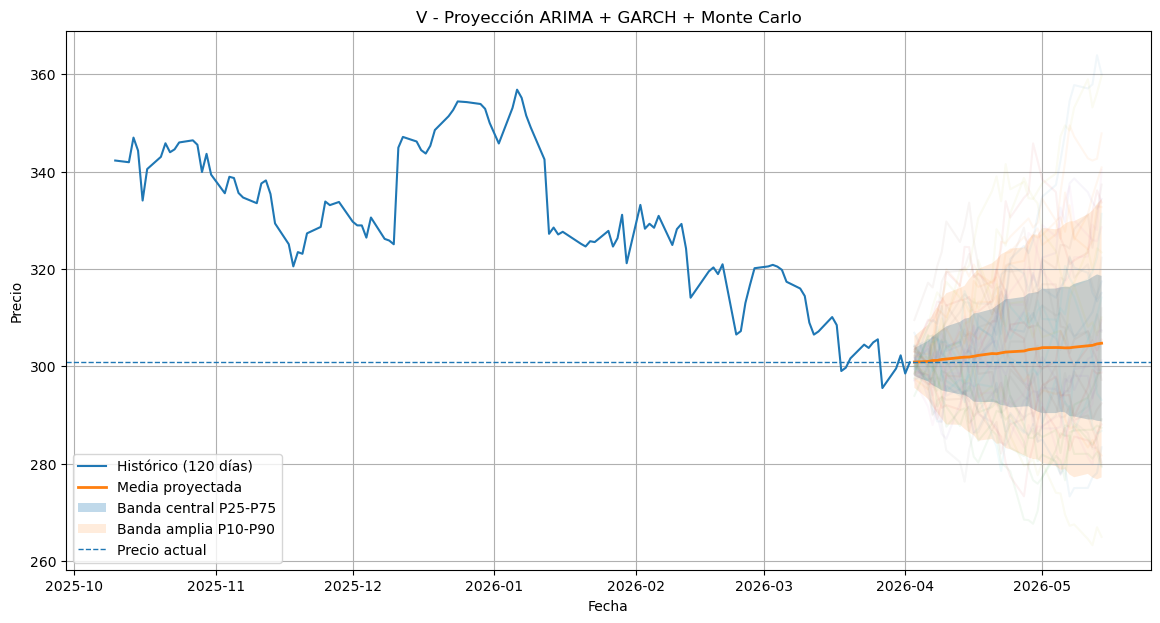


ANALISIS ROBUSTO: VOO

--- Comparación ARIMA (sí tiene sentido ahora) ---


,ARIMA,AIC,BIC
0,"(1, 0, 0)",-6519.221929,-6504.332359
1,"(2, 0, 0)",-6517.319651,-6497.466891
2,"(1, 0, 1)",-6517.168860,-6497.316100
3,"(2, 0, 1)",-6515.169232,-6490.353282
4,"(1, 1, 1)",-6504.872631,-6489.985900
5,"(2, 1, 1)",-6502.905178,-6483.056204
6,"(2, 1, 0)",-6170.022598,-6155.135868
7,"(1, 1, 0)",-6076.900371,-6066.975884



--- Resultado integrado ---
Ticker: VOO
Precio actual: 602.99
Tendencia técnica: MIXTA
RSI14: 47.49
Mejor ARIMA: (1, 0, 0)
AIC mejor ARIMA: -6519.22
BIC mejor ARIMA: -6504.33
Volatilidad GARCH día 1: 1.2196%
Precio esperado 30d: 612.07
Mediana 30d (P50): 611.26
P10: 558.10
P25: 583.06
P75: 639.13
P90: 665.79
Probabilidad de subir: 57.47%
Retorno esperado: 1.51%
Ancho banda P25-P75: 56.08
Ancho banda P10-P90: 107.68
Score final: 0
SEÑAL FINAL: ESPERAR

--- Interpretación de bandas Monte Carlo ---
P25-P75: banda central donde cae el 50% de los escenarios.
P10-P90: banda amplia donde cae el 80% de los escenarios.
Más ancha = más incertidumbre.


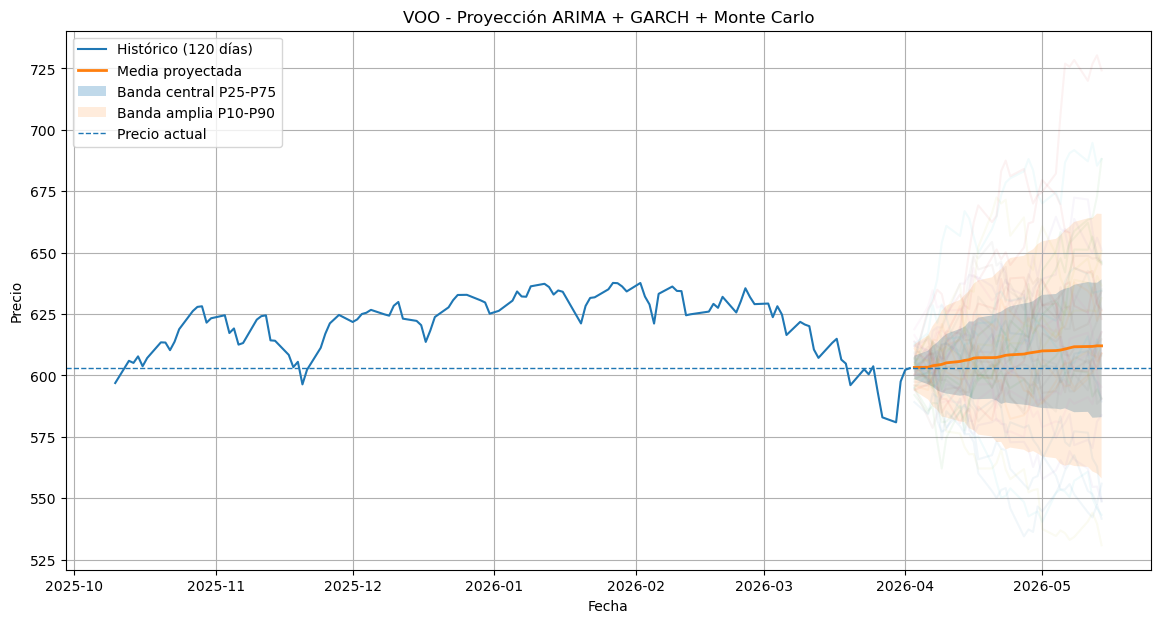


RESUMEN FINAL


,Ticker,Precio actual,Tendencia,RSI14,Mejor ARIMA,AIC,BIC,Vol GARCH d1 (%),Precio esperado 30d,P10,P25,P75,P90,Prob subir (%),Ret esp (%),Ancho P25-P75,Ancho P10-P90,Score,Señal final
1,VOO,602.99,MIXTA,47.49,"(1, 0, 0)",-6519.22,-6504.33,1.2196,612.07,558.10,583.06,639.13,665.79,57.47,1.51,56.08,107.68,0,ESPERAR
0,V,300.80,BAJISTA,42.91,"(1, 0, 0)",-6005.28,-5990.39,1.3748,304.73,277.16,288.68,318.56,334.36,55.33,1.31,29.88,57.20,-2,DESFAVORABLE


In [6]:
# ============================================================
# PROYECCION ROBUSTA Y SIMPLE PARA V y VOO
# Corrige:
# 1) La señal final ahora se calcula AL FINAL usando todo
# 2) ARIMA se compara contra varios candidatos por AIC/BIC
# 3) Monte Carlo muestra bandas percentiles claras
# 4) Menos riesgo de sobreajuste: grilla chica y modelo simple
#
# Requisitos:
# !pip install yfinance pandas numpy matplotlib statsmodels arch
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
TICKERS = ["V", "VOO"]
PERIODO = "5y"
DIAS_PROYECCION = 30
N_SIM = 1500
SEED = 42
np.random.seed(SEED)

# Grilla chica para no sobreajustar
ARIMA_CANDIDATOS = [
    (1, 0, 0),
    (1, 0, 1),
    (2, 0, 0),
    (2, 0, 1),
    (1, 1, 0),
    (1, 1, 1),
    (2, 1, 0),
    (2, 1, 1),
]

# ------------------------------------------------------------
# FUNCIONES
# ------------------------------------------------------------
def descargar_datos(ticker, period="5y"):
    df = yf.download(ticker, period=period, interval="1d", auto_adjust=True, progress=False)
    if df.empty:
        raise ValueError(f"No se pudieron descargar datos de {ticker}")

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    return df[["Close", "Volume"]].dropna().copy()

def calcular_rsi(serie, periodo=14):
    delta = serie.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(periodo).mean()
    avg_loss = loss.rolling(periodo).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

def preparar_indicadores(df):
    df = df.copy()
    df["MA20"] = df["Close"].rolling(20).mean()
    df["MA50"] = df["Close"].rolling(50).mean()
    df["MA100"] = df["Close"].rolling(100).mean()
    df["MA200"] = df["Close"].rolling(200).mean()
    df["RSI14"] = calcular_rsi(df["Close"], 14)
    df["RetLog"] = np.log(df["Close"] / df["Close"].shift(1))
    return df.dropna()

def clasificar_tendencia(df):
    ult = df.iloc[-1]
    prev = df.iloc[-2]

    precio = float(ult["Close"])
    ma20 = float(ult["MA20"])
    ma50 = float(ult["MA50"])
    ma100 = float(ult["MA100"])
    ma200 = float(ult["MA200"])
    rsi = float(ult["RSI14"])

    p20 = ult["MA20"] - prev["MA20"]
    p50 = ult["MA50"] - prev["MA50"]
    p200 = ult["MA200"] - prev["MA200"]

    if precio > ma20 > ma50 > ma100 > ma200 and p20 > 0 and p50 > 0:
        if rsi > 70:
            return "ALCISTA_EXTENDIDA"
        return "ALCISTA"

    if precio < ma20 < ma50 < ma100 < ma200 and p20 < 0 and p50 < 0:
        return "BAJISTA"

    if precio > ma200 and p200 >= 0:
        return "NEUTRA_ALCISTA"

    if precio < ma200 and p200 <= 0:
        return "NEUTRA_BAJISTA"

    return "MIXTA"

def seleccionar_arima(serie, candidatos):
    """
    Compara varios ARIMA y elige por menor AIC.
    También guarda BIC para revisión.
    """
    resultados = []

    for orden in candidatos:
        try:
            modelo = ARIMA(serie, order=orden)
            ajuste = modelo.fit()
            resultados.append({
                "orden": orden,
                "aic": ajuste.aic,
                "bic": ajuste.bic,
                "fit": ajuste
            })
        except:
            continue

    if len(resultados) == 0:
        raise ValueError("No se pudo ajustar ningún ARIMA.")

    tabla = pd.DataFrame([{
        "ARIMA": str(x["orden"]),
        "AIC": x["aic"],
        "BIC": x["bic"]
    } for x in resultados]).sort_values(["AIC", "BIC"]).reset_index(drop=True)

    mejor = sorted(resultados, key=lambda x: (x["aic"], x["bic"]))[0]
    return mejor["fit"], mejor["orden"], tabla

def ajustar_garch(retornos):
    """
    GARCH(1,1) simple para no sobrecargar el modelo.
    Retornos en %.
    """
    ret_pct = retornos * 100
    modelo = arch_model(ret_pct, mean="Zero", vol="Garch", p=1, q=1, dist="normal")
    ajuste = modelo.fit(disp="off")

    fc = ajuste.forecast(horizon=DIAS_PROYECCION, reindex=False)
    var_futura = fc.variance.values[-1]
    sigma_futura = np.sqrt(var_futura) / 100.0  # volver a log-retorno

    return ajuste, sigma_futura

def simular_arima_garch(precio_actual, drift, sigma, dias=30, n_sim=1000):
    sims = np.zeros((dias, n_sim))

    for j in range(n_sim):
        precios = [precio_actual]
        for t in range(dias):
            shock = np.random.normal(loc=drift[t], scale=sigma[t])
            precios.append(precios[-1] * np.exp(shock))
        sims[:, j] = precios[1:]

    return sims

def calcular_score_y_senal(df, resumen_mc, sigma_garch):
    """
    Señal final usando:
    - tendencia
    - RSI
    - probabilidad de subir
    - retorno esperado
    - volatilidad GARCH inicial
    """
    tendencia = clasificar_tendencia(df)
    rsi = float(df["RSI14"].iloc[-1])

    prob_subir = resumen_mc["prob_subir"]
    ret_esp = resumen_mc["ret_esperado_pct"]
    vol_d1 = sigma_garch[0] * 100

    score = 0

    # Tendencia
    if tendencia == "ALCISTA":
        score += 2
    elif tendencia == "NEUTRA_ALCISTA":
        score += 1
    elif tendencia == "BAJISTA":
        score -= 2
    elif tendencia == "NEUTRA_BAJISTA":
        score -= 1

    # RSI
    if 50 <= rsi <= 65:
        score += 1
    elif rsi < 40:
        score -= 1
    elif rsi > 75:
        score -= 1

    # Monte Carlo
    if prob_subir >= 58:
        score += 1
    elif prob_subir <= 45:
        score -= 1

    if ret_esp > 2:
        score += 1
    elif ret_esp < 0:
        score -= 1

    # Riesgo GARCH
    if vol_d1 > 2.5:
        score -= 1

    if score >= 3:
        senal = "FAVORABLE"
    elif score <= -2:
        senal = "DESFAVORABLE"
    else:
        senal = "ESPERAR"

    return score, senal, tendencia, rsi, vol_d1

def resumir_montecarlo(precio_actual, sims):
    finales = sims[-1, :]

    p10 = np.percentile(finales, 10)
    p25 = np.percentile(finales, 25)
    p50 = np.percentile(finales, 50)
    p75 = np.percentile(finales, 75)
    p90 = np.percentile(finales, 90)
    media = np.mean(finales)

    prob_subir = float(np.mean(finales > precio_actual) * 100)
    ret_esperado_pct = float((media / precio_actual - 1) * 100)

    return {
        "media_30d": media,
        "p10": p10,
        "p25": p25,
        "p50": p50,
        "p75": p75,
        "p90": p90,
        "prob_subir": prob_subir,
        "ret_esperado_pct": ret_esperado_pct,
        "ancho_25_75": p75 - p25,
        "ancho_10_90": p90 - p10
    }

def graficar_proyeccion(df, sims, ticker):
    hist = df["Close"].tail(120)
    precio_actual = float(df["Close"].iloc[-1])
    fechas_futuras = pd.bdate_range(start=df.index[-1], periods=DIAS_PROYECCION + 1)[1:]

    plt.figure(figsize=(14, 7))
    plt.plot(hist.index, hist.values, label="Histórico (120 días)")

    for i in range(min(40, sims.shape[1])):
        plt.plot(fechas_futuras, sims[:, i], alpha=0.06)

    media = np.mean(sims, axis=1)
    p10 = np.percentile(sims, 10, axis=1)
    p25 = np.percentile(sims, 25, axis=1)
    p75 = np.percentile(sims, 75, axis=1)
    p90 = np.percentile(sims, 90, axis=1)

    plt.plot(fechas_futuras, media, linewidth=2, label="Media proyectada")
    plt.fill_between(fechas_futuras, p25, p75, alpha=0.28, label="Banda central P25-P75")
    plt.fill_between(fechas_futuras, p10, p90, alpha=0.14, label="Banda amplia P10-P90")
    plt.axhline(precio_actual, linestyle="--", linewidth=1, label="Precio actual")

    plt.title(f"{ticker} - Proyección ARIMA + GARCH + Monte Carlo")
    plt.xlabel("Fecha")
    plt.ylabel("Precio")
    plt.legend()
    plt.grid(True)
    plt.show()

# ------------------------------------------------------------
# EJECUCION
# ------------------------------------------------------------
resumenes = []

for ticker in TICKERS:
    print("\n" + "=" * 70)
    print(f"ANALISIS ROBUSTO: {ticker}")
    print("=" * 70)

    # Datos
    df = descargar_datos(ticker, period=PERIODO)
    df = preparar_indicadores(df)

    precio_actual = float(df["Close"].iloc[-1])
    retornos = df["RetLog"].dropna()

    # 1) Selección ARIMA comparativa
    arima_fit, mejor_orden, tabla_arima = seleccionar_arima(retornos, ARIMA_CANDIDATOS)
    drift = np.array(arima_fit.forecast(steps=DIAS_PROYECCION))

    print("\n--- Comparación ARIMA (sí tiene sentido ahora) ---")
    display(tabla_arima)

    # 2) GARCH
    garch_fit, sigma_30 = ajustar_garch(retornos)

    # 3) Monte Carlo
    sims = simular_arima_garch(
        precio_actual=precio_actual,
        drift=drift,
        sigma=sigma_30,
        dias=DIAS_PROYECCION,
        n_sim=N_SIM
    )
    resumen_mc = resumir_montecarlo(precio_actual, sims)

    # 4) Señal final al final
    score, senal, tendencia, rsi, vol_d1 = calcular_score_y_senal(df, resumen_mc, sigma_30)

    # 5) Mostrar
    print("\n--- Resultado integrado ---")
    print(f"Ticker: {ticker}")
    print(f"Precio actual: {precio_actual:.2f}")
    print(f"Tendencia técnica: {tendencia}")
    print(f"RSI14: {rsi:.2f}")
    print(f"Mejor ARIMA: {mejor_orden}")
    print(f"AIC mejor ARIMA: {arima_fit.aic:.2f}")
    print(f"BIC mejor ARIMA: {arima_fit.bic:.2f}")
    print(f"Volatilidad GARCH día 1: {vol_d1:.4f}%")
    print(f"Precio esperado 30d: {resumen_mc['media_30d']:.2f}")
    print(f"Mediana 30d (P50): {resumen_mc['p50']:.2f}")
    print(f"P10: {resumen_mc['p10']:.2f}")
    print(f"P25: {resumen_mc['p25']:.2f}")
    print(f"P75: {resumen_mc['p75']:.2f}")
    print(f"P90: {resumen_mc['p90']:.2f}")
    print(f"Probabilidad de subir: {resumen_mc['prob_subir']:.2f}%")
    print(f"Retorno esperado: {resumen_mc['ret_esperado_pct']:.2f}%")
    print(f"Ancho banda P25-P75: {resumen_mc['ancho_25_75']:.2f}")
    print(f"Ancho banda P10-P90: {resumen_mc['ancho_10_90']:.2f}")
    print(f"Score final: {score}")
    print(f"SEÑAL FINAL: {senal}")

    # Explicación corta de bandas
    print("\n--- Interpretación de bandas Monte Carlo ---")
    print("P25-P75: banda central donde cae el 50% de los escenarios.")
    print("P10-P90: banda amplia donde cae el 80% de los escenarios.")
    print("Más ancha = más incertidumbre.")

    # 6) Gráfico
    graficar_proyeccion(df, sims, ticker)

    resumenes.append({
        "Ticker": ticker,
        "Precio actual": round(precio_actual, 2),
        "Tendencia": tendencia,
        "RSI14": round(rsi, 2),
        "Mejor ARIMA": str(mejor_orden),
        "AIC": round(arima_fit.aic, 2),
        "BIC": round(arima_fit.bic, 2),
        "Vol GARCH d1 (%)": round(vol_d1, 4),
        "Precio esperado 30d": round(resumen_mc["media_30d"], 2),
        "P10": round(resumen_mc["p10"], 2),
        "P25": round(resumen_mc["p25"], 2),
        "P75": round(resumen_mc["p75"], 2),
        "P90": round(resumen_mc["p90"], 2),
        "Prob subir (%)": round(resumen_mc["prob_subir"], 2),
        "Ret esp (%)": round(resumen_mc["ret_esperado_pct"], 2),
        "Ancho P25-P75": round(resumen_mc["ancho_25_75"], 2),
        "Ancho P10-P90": round(resumen_mc["ancho_10_90"], 2),
        "Score": score,
        "Señal final": senal
    })

# ------------------------------------------------------------
# TABLA FINAL
# ------------------------------------------------------------
tabla_final = pd.DataFrame(resumenes)
print("\n" + "=" * 70)
print("RESUMEN FINAL")
print("=" * 70)
display(tabla_final.sort_values("Score", ascending=False))